In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import xarray as xr

Submitted batch job 355505


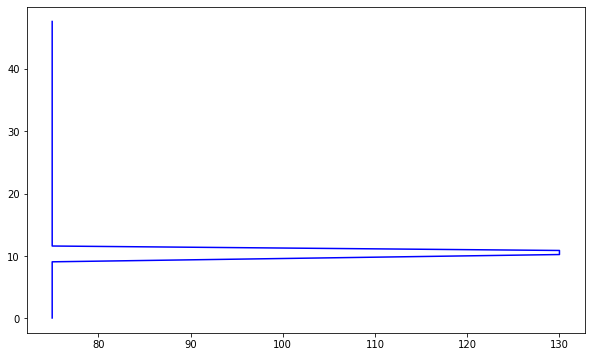

In [26]:
# Import new profile to APCEMM met file
# Open the NetCDF file for writing

# Create new met file to edit with RH data
######################################################################################
#MUST ALSO EDIT IN /home/chinahg/GCresearch/APCEMM/rundirs/SampleRunDir/updateYAML.py
######################################################################################
max_RH = 130 #130%
moist_layer_depth = 1 # [km]
shape = "rect"
flight_alt = 10.358 # [km]
######################################################################################

area = str(max_RH*moist_layer_depth)

######################################################################################
### CREATE DISCRETE RH DATA TO FEED INTO APCEMM
######################################################################################

altitude = [0.0706847161054611, 0.280354559421539, 0.494257032871246, 
    0.71270889043808, 0.936570823192596, 1.16609489917755, 1.40123450756073, 
    1.64200806617737, 1.88862943649292, 2.14136052131653, 2.40070509910583, 
    2.94195675849915, 3.51732301712036, 4.13245820999146, 4.79369401931763, 
    5.50710439682007, 6.27960538864136, 7.12048578262329, 8.04355049133301, 
    9.07177543640137, 10.2383241653442, 10.8901128768921, 11.6034088134766, 
    12.4268131256104, 13.4131603240967, 14.5604238510132, 15.9659404754639, 
    18.1929683685303, 20.2443885803223, 23.3482246398926, 25.7990627288818, 
    30.0542526245117, 32.3974838256836, 34.8223838806152, 38.9491233825684, 
    42.2613258361816, 47.5921516418457]

RH = np.zeros_like(altitude)
for i in range(len(RH)):
    if (altitude[i] >= (flight_alt - moist_layer_depth/2)) & (altitude[i] <= (flight_alt + moist_layer_depth/2)):
        RH[i] = max_RH
    else:
        RH[i] = 75 # ARBITRARY, could change lower limit
######################################################################################

plt.figure(figsize=(10, 6))
plt.plot(RH, altitude, linestyle='-', color='b')

met_name = "met_" + shape + "_" + area
dest_dir = '/home/chinahg/GCresearch/contrailuncertainty/APCEMM_results'
src_file = '/home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/example_met_file.nc'
shutil.copy(src_file,dest_dir) #copy the file to destination dir
dst_file = os.path.join(dest_dir,'example_met_file.nc')
new_dst_file_name = os.path.join(dest_dir, met_name + '.nc')
# os.rename(dst_file, new_dst_file_name) #rename

# Edit nc file with RH profiles
nc_file = xr.open_dataset(src_file)

# Modify its values
#print(nc_file['relative_humidity'][:])
nc_file['relative_humidity'][:] = RH

# Close the NetCDF file to save changes
nc_file.to_netcdf(new_dst_file_name)
nc_file.close()


# Then, run APCEMM with modified netCDF input file (see example 3)
!sbatch /home/chinahg/GCresearch/APCEMM/rundirs/SampleRunDir/uncertainty.sh

In [27]:
!ncdump /home/chinahg/GCresearch/APCEMM/examples/Example3_met_input/example_met_file.nc

netcdf example_met_file {
dimensions:
	altitude = 37 ;
	time = 24 ;
variables:
	double altitude(altitude) ;
		altitude:units = "km" ;
	double time(time) ;
		time:units = "s" ;
	double var_length ;
		var_length:units = "-" ;
	double pressure(altitude) ;
		pressure:units = "hPa" ;
	double temperature(altitude, time) ;
		temperature:units = "K" ;
	double relative_humidity(altitude) ;
		relative_humidity:units = "Pct" ;
	double relative_humidity_ice(altitude) ;
		relative_humidity_ice:units = "Pct" ;
	double shear(altitude, time) ;
		shear:units = "s^-1" ;
	double flight_altitude ;
		flight_altitude:units = "hPa" ;
	double soot_emission_index ;
		soot_emission_index:units = "g/kg" ;
	double soot_radius ;
		soot_radius:units = "m" ;
	double fuel_flow_rate ;
		fuel_flow_rate:units = "kg/s" ;
	double aircraft_mass ;
		aircraft_mass:units = "kg" ;
	double flight_velocity ;
		flight_velocity:units = "m/s" ;
	double number_engines ;
		number_engines:units = "-" ;
	double wingspan ;
		wingspan:un